# Estadística para Ingeniería

La estadística no existe para calcular números.

Existe para responder preguntas.

Preguntas como:

- ¿Cuál es el comportamiento típico de un sistema?
- ¿Qué tan variable es?
- ¿Existen comportamientos anómalos?
- ¿Se observan patrones?
- ¿Existe relación entre variables?
- ¿Podemos tomar decisiones con confianza?

En esta sesión aprenderemos los conceptos estadísticos más utilizados en ingeniería y cómo aplicarlos utilizando Python.

# Concepto 1: Media (Promedio)

## Pregunta que responde

¿Cuál es el comportamiento típico del sistema?

### Fórmula

$
\bar{x}=\frac{x_1+x_2+\cdots+x_n}{n}
$

donde:

- $x_i$ representa cada observación
- $n$ representa el número total de observaciones

La media es probablemente la métrica más utilizada en ingeniería.

In [2]:
import numpy as np

datos = [5, 6, 7, 8, 9]

np.mean(datos)

np.float64(7.0)

Interpretación:

En promedio el valor observado es 7.

Pero...

¿Representa siempre correctamente la realidad?

In [2]:
datos = [5, 6, 7, 8, 100]

np.mean(datos)

np.float64(25.2)

Observemos cómo un único valor extremo afecta el promedio.

Ahora aparece una nueva pregunta:

¿Existe una medida más robusta?

# Mediana

## Pregunta que responde

¿Qué ocurre la mayor parte del tiempo?

La mediana corresponde al valor central de los datos ordenados.

### Fórmula conceptual

1. Ordenar los datos.
2. Seleccionar el valor central.

La mediana es menos sensible a valores extremos.

In [4]:
datos = [-100,1,2,5,5, 6, 7, 8, 100,200]

print("Media:", np.mean(datos))
print("Mediana:", np.median(datos))

Media: 23.4
Mediana: 5.5


¿Cuál representa mejor el comportamiento habitual del sistema?

La media o la mediana.

# Rango

## Pregunta que responde

¿Cuál fue el mejor escenario?

¿Cuál fue el peor escenario?

### Fórmula

$
Rango = Máximo - Mínimo
$

In [4]:
datos = [15, 18, 20, 22, 31]

rango = max(datos) - min(datos)

rango

16

# Desviación estándar

## Pregunta que responde

¿Qué tan estable es el sistema?

### Fórmula

$
s=\sqrt{\frac{\sum (x_i-\bar{x})^2}{n-1}}
$

No necesitamos memorizar la fórmula.

Lo importante es entender la idea:

Mide qué tan dispersos están los datos respecto al promedio.

In [5]:
estacion_a = [5, 5, 5, 5, 5]

estacion_b = [1, 9, 5, 8, 2]

print(np.mean(estacion_a))
print(np.mean(estacion_b))

5.0
5.0


In [6]:
print(np.std(estacion_a))
print(np.std(estacion_b))

0.0
3.1622776601683795


Aunque ambas tienen un promedio similar,
su comportamiento es completamente diferente.

Una es estable.

La otra es altamente variable.

# Generando datos simulados

Hasta ahora hemos trabajado con pocos datos.

Para algunos ejemplos estadísticos necesitaremos conjuntos de datos más grandes.

Python puede generar datos simulados siguiendo diferentes distribuciones estadísticas.

Una de las más importantes es la distribución normal (o distribución gaussiana), muy utilizada en ingeniería.

Muchos fenómenos físicos presentan comportamientos aproximados a una distribución normal:

- Errores de medición.
- Temperaturas.
- Variables meteorológicas.
- Procesos industriales.
- Resultados experimentales.

## Función utilizada

```python
np.random.normal(media, desviacion_estandar, numero_de_datos)

In [5]:
datos = np.random.normal(
     loc=100, # media 
     scale=20, # desviación estándar 
     size=1000 # cantidad de datos 
)

In [7]:
datos

array([129.97139323,  65.76352588, 120.90924264, 102.77716733,
       108.54697866,  92.15018983,  81.11401505,  97.31928814,
        88.05645958,  81.43627213, 113.48367917, 100.53501939,
        98.46515433,  91.55141983, 110.20065651,  87.01029637,
        67.90209269, 110.2521615 ,  77.58168754,  93.55848043,
        80.67437177, 111.9242527 , 122.72805477,  88.58213032,
       104.775007  , 105.73217494, 141.69998387, 105.81727748,
       107.63075334,  76.69849663, 136.87817446,  84.29582247,
        88.99913417, 100.55701244, 105.35670385, 138.68926633,
        88.46188046,  98.59164058,  69.08213904,  88.47887448,
        92.4316669 , 103.63696929, 113.52606607,  98.92053462,
        98.9599426 , 105.15479212,  88.07298581, 101.40930665,
        97.98272428,  88.02774961, 107.84068592, 108.52561693,
        50.83549776, 131.34520526, 131.75474065, 106.30217535,
       107.16596883, 105.62822421, 130.75046805,  79.30077418,
       101.01057491, 122.86060211, 125.30743861, 131.35

Hemos generado 1000 observaciones simuladas.

Estas observaciones tienen aproximadamente:

- Media = 100
- Desviación estándar = 20

Cada vez que ejecutemos la celda obtendremos valores ligeramente diferentes, ya que se generan aleatoriamente.

In [6]:
print("Media:", np.mean(datos))
print("Desviación estándar:", np.std(datos))

Media: 99.03449628819469
Desviación estándar: 19.5938904209593


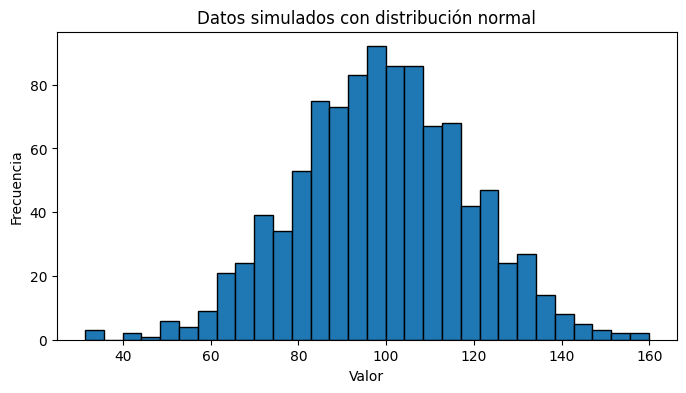

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(
    datos,
    bins=30,
    edgecolor="black"
)

plt.title(
    "Datos simulados con distribución normal"
)

plt.xlabel("Valor")
plt.ylabel("Frecuencia")

plt.show()

Observe que:

- La mayoría de los valores se concentran cerca del promedio.
- Los valores muy bajos y muy altos ocurren con menor frecuencia.
- Esta forma es característica de una distribución normal.

# Percentiles

Una vez tenemos nuestros datos, podemos calcular percentiles.

Los percentiles permiten responder preguntas como:

- ¿Qué ocurre la mayor parte del tiempo?
- ¿Qué valores son inusualmente altos?
- ¿Cuál es el límite superior esperado para un proceso?

Por ejemplo:

## Percentil 95

El 95 % de las observaciones se encuentra por debajo de este valor.

In [12]:
percentil_95 = np.percentile(
    datos,
    95
)

percentil_95

np.float64(132.32550077433925)

Interpretación:

Si el percentil 95 es 133, significa que aproximadamente el 95 % de los datos está por debajo de 133.

Solamente el 5 % de las observaciones supera ese valor.

# ¿Para qué sirven realmente los percentiles en ingeniería?

Hasta ahora hemos calculado percentiles utilizando Python.

Sin embargo, la pregunta más importante es:

> ¿Por qué un ingeniero utilizaría percentiles en lugar de simplemente calcular un promedio?

La respuesta es sencilla:

Los sistemas reales no operan siempre en condiciones promedio.

Cuando diseñamos equipos, procesos o infraestructuras, debemos considerar escenarios exigentes pero realistas.

Por esta razón, en muchas aplicaciones se utilizan percentiles.

---

# 1. Diseño de transformadores

Supongamos que analizamos la demanda eléctrica de un edificio durante un año.

La pregunta sería:

> ¿Qué capacidad debería tener el transformador?

Si utilizamos únicamente el promedio de demanda:

$
\bar{P}
$

podríamos subdimensionar el equipo.

Durante algunos periodos la demanda puede ser significativamente mayor.

Por esta razón se suelen utilizar valores altos de la distribución, como:

- Percentil 95
- Percentil 99

Interpretación:

> El percentil 95 indica una potencia que solamente es superada el 5% del tiempo.

De esta forma el transformador puede soportar prácticamente todas las condiciones normales de operación sin sobredimensionarlo excesivamente.

---

# 2. Dimensionamiento de alimentadores eléctricos

Los conductores eléctricos deben transportar corriente de forma segura.

La pregunta es:

> ¿Qué corriente debemos considerar para seleccionar el conductor?

Nuevamente, el promedio puede ser engañoso.

Un conductor diseñado únicamente para la corriente promedio podría calentarse excesivamente durante periodos de alta carga.

Por esta razón suelen analizarse:

- máximos
- percentiles altos
- curvas de carga

Ejemplo:

Si el percentil 95 de corriente es 180 A, significa que el conductor deberá soportar aproximadamente ese nivel de carga durante las condiciones habituales más exigentes.

---

# 3. Análisis de demanda eléctrica

Una empresa desea conocer cómo se comporta su consumo.

Pregunta:

> ¿Cuál es la demanda habitual y cuál es la demanda crítica?

Aquí podemos utilizar varios estadísticos:

Media:

$
\bar{P}
$

Desviación estándar:

$
s
$

Percentiles:

$
P_{95}
$

Interpretación:

- Media → comportamiento típico.
- Desviación estándar → variabilidad.
- Percentil 95 → escenarios exigentes.

Cada uno responde una pregunta diferente.

---

# 4. Velocidad del viento

En proyectos eólicos la velocidad del viento presenta una alta variabilidad.

La pregunta es:

> ¿Qué tan favorable es un sitio para instalar aerogeneradores?

Podemos calcular:

- Media de velocidad.
- Percentiles.
- Distribuciones.

Ejemplo:

Un sitio puede tener una velocidad media elevada, pero también una gran variabilidad.

Esto afecta:

- producción energética,
- estabilidad del recurso,
- rentabilidad del proyecto.

Los percentiles permiten identificar qué velocidades ocurren la mayor parte del tiempo.

---

# 5. Irradiancia solar

Imaginemos que queremos evaluar el potencial solar de una ubicación.

Pregunta:

> ¿Qué nivel de irradiancia podemos esperar normalmente?

La irradiancia cambia debido a:

- nubosidad,
- estaciones climáticas,
- variabilidad atmosférica.

El promedio ofrece una visión general:

$
\bar{GHI}
$

Sin embargo, los percentiles permiten entender:

- escenarios favorables,
- escenarios desfavorables,
- incertidumbre del recurso.

Esto es especialmente importante durante estudios de factibilidad.

---

# 6. Diseño de sistemas fotovoltaicos

Una de las preguntas más frecuentes es:

> ¿Cuánta energía generará el sistema?

En lugar de responder con un único valor promedio, los ingenieros suelen construir escenarios.

Por ejemplo:

- Escenario conservador → Percentil 5
- Escenario esperado → Mediana
- Escenario optimista → Percentil 95

Esto permite realizar análisis financieros más realistas.

---

# Conclusión

La estadística no sirve únicamente para describir datos.

Sirve para tomar decisiones.

Cada métrica responde una pregunta diferente:

| Métrica | Pregunta que responde |
|----------|----------------------|
| Media | ¿Cuál es el comportamiento típico? |
| Mediana | ¿Qué ocurre la mayor parte del tiempo? |
| Máximo | ¿Cuál fue el mejor escenario? |
| Mínimo | ¿Cuál fue el peor escenario? |
| Desviación estándar | ¿Qué tan estable es el sistema? |
| Percentiles | ¿Qué ocurre bajo condiciones exigentes pero realistas? |

Por esta razón, en ingeniería rara vez basta con conocer un promedio.

Necesitamos entender también la variabilidad y el riesgo asociado a los datos.

# Aplicación práctica de estadística a datos reales

## Un problema de ingeniería

Supongamos que una empresa está evaluando el comportamiento climático de una ubicación para analizar posibles oportunidades energéticas.

Disponemos de información proveniente de NASA POWER:

- Temperatura ambiente
- Velocidad de viento
- Irradiancia solar

Nuestro objetivo será actuar como analistas e ingenieros.

No vamos a memorizar fórmulas.

Vamos a responder preguntas utilizando estadística.

Durante este análisis aprenderemos:

- Cómo explorar un conjunto de datos.
- Cómo describir una variable.
- Cómo medir variabilidad.
- Cómo identificar escenarios críticos.
- Cómo encontrar relaciones entre variables.
- Cómo convertir datos en decisiones.

In [14]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")


# Obtención de datos reales desde NASA POWER

Hasta ahora hemos trabajado con ejemplos pequeños para comprender los conceptos estadísticos.

Ahora utilizaremos datos reales obtenidos desde NASA POWER.

NASA POWER es una plataforma que proporciona información meteorológica y climatológica para cualquier ubicación del planeta.

Vamos a descargar:

- Temperatura del aire (T2M)
- Velocidad del viento a 2 metros (WS2M)
- Irradiancia solar sobre superficie horizontal (ALLSKY_SFC_SW_DWN)

Estas variables son ampliamente utilizadas en:

- Gestión energética
- Estudios de eficiencia energética
- Energía solar
- Energía eólica
- Planeación energética

---

# ¿Qué vamos a hacer?

1. Solicitar datos a la API de NASA.
2. Recibir la respuesta en formato JSON.
3. Convertir el JSON en un DataFrame.
4. Aplicar herramientas estadísticas para extraer conocimiento.

In [15]:
lat = 4.7110
lon = -74.0721

start_date = "20240101"
end_date = "20241231"

In [18]:
url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    "?parameters=T2M,WS2M,ALLSKY_SFC_SW_DWN"
    "&community=RE"
    f"&latitude={lat}"
    f"&longitude={lon}"
    f"&start={start_date}"
    f"&end={end_date}"
    "&format=JSON"
)

url

'https://power.larc.nasa.gov/api/temporal/hourly/point?parameters=T2M,WS2M,ALLSKY_SFC_SW_DWN&community=RE&latitude=4.711&longitude=-74.0721&start=20240101&end=20241231&format=JSON'

In [ ]:
lat = 4.7110
lon = -74.0721

url = (
    "https://power.larc.nasa.gov/api/temporal/hourly/point"
    "?parameters=WS2M"
    "&community=RE"
    f"&latitude={lat}"
    f"&longitude={lon}"
    f"&start={start_date}"
    f"&end={end_date}"
    "&format=JSON"
)

response = requests.get(url)
data = response.json()

viento = data["properties"]["parameter"]["WS2M"]

df = pd.DataFrame({    
    "Velocidad_Viento": viento
})

# Paso 1. Conociendo el conjunto de datos

La primera pregunta que debe hacerse cualquier analista es:

> ¿Qué tengo entre manos?

Antes de calcular estadísticos o construir gráficas necesitamos entender:

- Número de registros.
- Variables disponibles.
- Tipo de información.
- Calidad de los datos.

Muchas veces esta etapa permite descubrir problemas antes de iniciar el análisis.

In [20]:
df.head()

,Temperatura,Velocidad_Viento,Irradiancia
2024010100,16.42,0.48,0.0
2024010101,16.07,0.55,0.0
2024010102,15.79,0.61,0.0
2024010103,15.45,0.70,0.0
2024010104,15.18,0.78,0.0


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8784 entries, 2024010100 to 2024123123
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Temperatura       8784 non-null   float64
 1   Velocidad_Viento  8784 non-null   float64
 2   Irradiancia       8784 non-null   float64
dtypes: float64(3)
memory usage: 274.5+ KB


In [22]:
df.shape

(8784, 3)

# Paso 2. Resumen estadístico general

Ahora queremos responder la siguiente pregunta:

> ¿Cómo se comportan nuestras variables?

Python puede generar un resumen estadístico de forma automática.

Utilizaremos:

```python
df.describe()
```

Esta función calcula:

- cantidad de datos
- media
- desviación estándar
- mínimo
- percentiles
- máximo

Es una de las herramientas más utilizadas en análisis de datos.

In [23]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperatura,8784.0,19.669712,3.611074,11.05,16.77,18.91,22.6700,29.36
Velocidad_Viento,8784.0,1.187086,0.773334,0.03,0.66,0.96,1.5100,5.15
Irradiancia,8784.0,198.016514,264.011507,0.00,0.00,3.41,411.4675,1006.33


In [24]:
df.mean(numeric_only=True)

Temperatura          19.669712
Velocidad_Viento      1.187086
Irradiancia         198.016514
dtype: float64